<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/ML_EjercicioRegresion2_AlanisSebastian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ajuste y selección de un modelo de regresión (Insurance Charges)

**Definición del problema**

El dataset `insurance.csv` contiene información demográfica y de estilo de vida de distintas personas, como edad, índice de masa corporal, número de hijos, hábito de fumar y región, junto con el costo médico asociado a cada individuo, representado por la variable `charges`.

El problema consiste en modelar la relación entre estas variables explicativas y el costo médico con el fin de entender qué factores influyen en dicho costo y en qué magnitud lo hacen. Para ello se utilizará un modelo de regresión lineal, el cual permite expresar el valor esperado de `charges` como una combinación lineal de las variables disponibles en el dataset.

Además de ajustar el modelo, también es necesario analizar si las relaciones estimadas entre las variables tienen sustento estadístico, evaluar si el modelo cumple con los supuestos clásicos de la regresión lineal y examinar qué tan bien logra explicar la variabilidad observada en los datos.

**Objetivo**

El objetivo es ajustar y evaluar un modelo de regresión lineal para predecir la variable `charges` utilizando la información contenida en el dataset `insurance.csv`.

Para lograrlo se implementará una función paramétrica que permita ajustar el modelo bajo distintas configuraciones. Entre estas configuraciones se considerará la proporción de datos utilizada para entrenamiento, la posibilidad de realizar análisis gráfico exploratorio y la aplicación de transformaciones sobre las variables mediante la clase `PrepGener`.

Posteriormente se evaluará cada configuración utilizando métricas de desempeño, pruebas estadísticas y análisis de los supuestos del modelo. Finalmente, se seleccionará la configuración que proporcione el mejor desempeño y se realizará una interpretación de los resultados obtenidos, analizando qué variables influyen en el costo médico y cómo lo hacen dentro del modelo estimado.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Preparación del entorno

En este notebook se uti algunas bibliotecas de Python necesarias para manejar los datos, ajustar el modelo de regresión y realizar el análisis estadístico correspondiente.

- `pandas` y `numpy` se utilizan para la lectura y manipulación del dataset, así como para operaciones numéricas.
- `statsmodels` se emplea para ajustar el modelo de regresión OLS y obtener resultados de inferencia estadística como pruebas t, prueba F y ANOVA.
- `scipy` se usa para realizar pruebas estadísticas adicionales, como la prueba de normalidad de Shapiro.
- `sklearn` se utiliza para dividir el dataset en conjuntos de entrenamiento y prueba.
- `matplotlib` permite generar las gráficas necesarias para visualizar los resultados del modelo.

El archivo del dataset en este entorno se encuentra en Drive la siguiente ruta:

- `/content/drive/MyDrive/PROY3 ANAL/insurance.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.anova import anova_lm

from scipy import stats
from sklearn.model_selection import train_test_split
import pandas.plotting as pd_plotting

# Lectura del dataset
path = "/content/drive/MyDrive/PROY3 ANAL/insurance.csv"
df = pd.read_csv(path)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2) Entendimiento del dataset

El dataset `insurance.csv` contiene información demográfica y de estilo de vida de distintos individuos, junto con el costo médico asociado a cada uno. La variable que se busca modelar es `charges`, la cual representa el gasto médico individual.

Las variables presentes en el dataset son:

- `charges`: variable objetivo continua que representa el costo médico.
- `age`: edad del individuo, variable numérica.
- `sex`: sexo del individuo, variable categórica.
- `bmi`: índice de masa corporal, variable numérica que refleja la relación entre peso y estatura.
- `children`: número de hijos o dependientes cubiertos por el seguro, variable numérica discreta.
- `smoker`: indica si la persona es fumadora o no, variable categórica.
- `region`: región geográfica donde vive el individuo, variable categórica.

Antes de ajustar el modelo es necesario revisar algunas características básicas del dataset, como sus dimensiones y un resumen estadístico de las variables. Esto permite tener una primera idea sobre la estructura de los datos y posibles patrones generales.

In [ ]:
df.shape, df.describe(include="all").T

((1338, 7),
            count unique        top  freq          mean           std  \
 age       1338.0    NaN        NaN   NaN     39.207025      14.04996   
 sex         1338      2       male   676           NaN           NaN   
 bmi       1338.0    NaN        NaN   NaN     30.663397      6.098187   
 children  1338.0    NaN        NaN   NaN      1.094918      1.205493   
 smoker      1338      2         no  1064           NaN           NaN   
 region      1338      4  southeast   364           NaN           NaN   
 charges   1338.0    NaN        NaN   NaN  13270.422265  12110.011237   
 
                 min         25%       50%           75%          max  
 age            18.0        27.0      39.0          51.0         64.0  
 sex             NaN         NaN       NaN           NaN          NaN  
 bmi           15.96    26.29625      30.4      34.69375        53.13  
 children        0.0         0.0       1.0           2.0          5.0  
 smoker          NaN         NaN       NaN

## 3) Análisis exploratorio gráfico

Antes de ajustar el modelo de regresión es conveniente realizar un análisis exploratorio visual de los datos. Este paso permite observar cómo se comportan las variables, identificar posibles relaciones entre ellas y detectar características que podrían influir en el modelo, como patrones no lineales, valores extremos o distribuciones muy sesgadas.

En particular, interesa examinar cómo se relacionan las variables numéricas con la variable `charges`, ya que esto puede dar una primera idea de qué variables podrían tener mayor influencia en el costo médico. También es útil revisar si existen diferencias visibles entre distintos grupos de individuos, por ejemplo entre fumadores y no fumadores.

Para este análisis se utilizarán dos tipos de gráficos:

- **Matrix-scatter plot** de las variables numéricas, con gráficas de densidad en la diagonal. Esto permite observar de manera simultánea las relaciones entre las variables numéricas del dataset.

- **Gráfica de densidad de `charges`**, que ayuda a entender la forma de la distribución del costo médico y a detectar posibles colas largas o valores extremos.

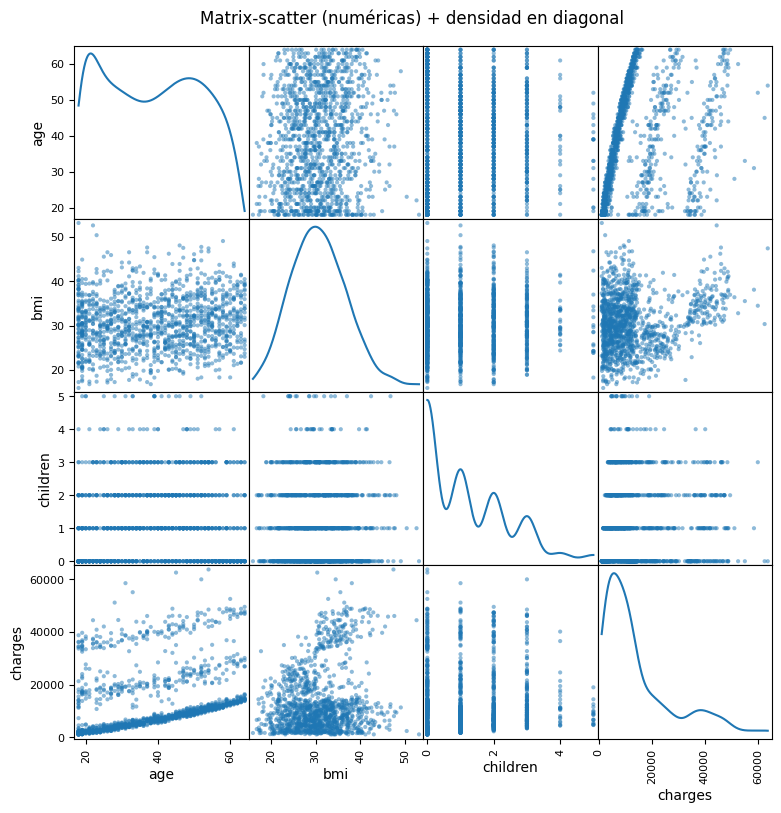

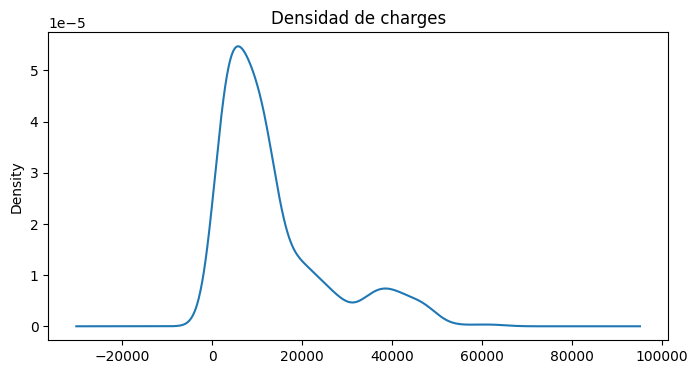

In [ ]:
def exploratory_plots(data: pd.DataFrame, y="charges"):
    num_cols = ["age","bmi","children","charges"]
    pd_plotting.scatter_matrix(data[num_cols], figsize=(9,9), diagonal="kde")
    plt.suptitle("Matrix-scatter (numéricas) + densidad en diagonal", y=0.92)
    plt.show()

    plt.figure(figsize=(8,4))
    data[y].plot(kind="density")
    plt.title(f"Densidad de {y}")
    plt.show()

exploratory_plots(df)

## 4) Definiciones

Antes de presentar los resultados del modelo es útil definir las métricas y pruebas estadísticas que se utilizarán para evaluarlo. Estas herramientas permiten analizar tanto la capacidad predictiva del modelo como la validez estadística de sus resultados.

### 4.1 Métricas de desempeño

Estas métricas permiten medir qué tan bien el modelo reproduce los valores reales de `charges`.

- **MSE (Mean Squared Error)**: mide el promedio del cuadrado de los errores de predicción. Penaliza fuertemente los errores grandes, por lo que es sensible a predicciones muy alejadas del valor real.

- **RMSE (Root Mean Squared Error)**: es la raíz cuadrada del MSE. Tiene las mismas unidades que `charges`, lo que facilita interpretar el tamaño promedio del error de predicción.

- **MAPE (Mean Absolute Percentage Error)**: mide el error promedio en términos porcentuales. Es una métrica intuitiva porque permite interpretar el error relativo del modelo. Puede ser inestable cuando los valores reales son cercanos a cero, aunque en este dataset `charges` generalmente toma valores suficientemente grandes.

- **R² y R² ajustada**:
  - `R²` mide la proporción de la variabilidad de la variable objetivo que es explicada por el modelo.
  - `R² ajustada` corrige este valor considerando el número de variables incluidas en el modelo, por lo que es más adecuada cuando se comparan modelos con distinto número de predictores.

### 4.2 Pruebas estadísticas

Además de medir el error del modelo, también se realizan pruebas estadísticas que permiten evaluar la significancia de las variables y verificar supuestos del modelo de regresión.

- **t-test en betas**: evalúa si cada coeficiente del modelo es estadísticamente distinto de cero. Esto permite determinar si una variable tiene evidencia estadística de influir en `charges`.

- **F-test global**: evalúa si el modelo completo tiene capacidad explicativa. En términos simples, contrasta el modelo estimado contra un modelo que solo contiene intercepto.

- **ANOVA**: permite descomponer la variabilidad total de la variable objetivo en una parte explicada por el modelo y otra asociada al error.

- **Normalidad de residuales**: se utilizan pruebas como Shapiro, Jarque–Bera o Anderson–Darling para evaluar si los errores del modelo siguen una distribución aproximadamente normal. En muestras grandes es común obtener p-values pequeños incluso cuando el modelo es razonable, pero se reportan de cualquier forma como parte del diagnóstico.

- **VIF (Variance Inflation Factor)**: mide el grado de multicolinealidad entre las variables explicativas. Valores altos indican que algunas variables están fuertemente correlacionadas entre sí. Una regla común es considerar valores mayores a 10 como potencialmente problemáticos.

- **Prueba de Breusch–Pagan**: se utiliza para detectar heterocedasticidad, es decir, si la varianza de los residuales cambia a lo largo de los valores predichos por el modelo.

In [ ]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    eps = 1e-12
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred))**2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def adjusted_r2(r2, n, p):
    # p = número de predictores (sin intercepto)
    return 1 - (1 - r2) * (n - 1) / max(n - p - 1, 1)

def compute_vif_from_design(exog_df: pd.DataFrame) -> pd.DataFrame:
    X = exog_df.copy()
    if "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])
    const_cols = [c for c in X.columns if np.isclose(X[c].var(ddof=0), 0)]
    X = X.drop(columns=const_cols, errors="ignore")

    vifs = []
    for i, col in enumerate(X.columns):
        vifs.append((col, variance_inflation_factor(X.values, i)))
    return pd.DataFrame(vifs, columns=["variable", "VIF"]).sort_values("VIF", ascending=False)

## 5) Transformaciones (clase `PrepGener`)

Antes de ajustar el modelo puede ser útil aplicar ciertas transformaciones a las variables. En modelos de regresión lineal, las transformaciones ayudan a mejorar el comportamiento estadístico de los datos y, en algunos casos, a obtener modelos más estables o interpretables.

Una transformación común es aplicar logaritmo a la variable objetivo `charges`. Esto puede ser útil cuando la distribución presenta colas largas o cuando existe heterocedasticidad, es decir, cuando la variabilidad de los errores cambia a lo largo de los valores predichos.

Otra transformación frecuente es estandarizar las variables numéricas mediante **z-score**, lo cual consiste en centrar las variables en su media y escalarlas por su desviación estándar. Esto no cambia la relación entre las variables, pero puede facilitar la comparación entre coeficientes y mejorar la estabilidad numérica del modelo.

Para manejar estas transformaciones se implementa una clase llamada `PrepGener`, la cual permite controlar el preprocesamiento de forma flexible. Esta clase incluye dos parámetros principales:

- `y_transform`: puede tomar el valor `None` o `"log"` para indicar si se aplicará una transformación logarítmica a la variable objetivo.
- `x_scale`: puede tomar el valor `None` o `"zscore"` para indicar si se estandarizarán las variables numéricas.

Es importante considerar que, si el modelo se entrena utilizando `log(charges)` como variable objetivo, las predicciones obtenidas estarán en escala logarítmica. Por lo tanto, para evaluar correctamente las métricas de desempeño en la escala original de `charges`, se aplicará la función `exp()` a las predicciones antes de calcular los errores.

In [ ]:
from dataclasses import dataclass
from typing import Optional, List, Dict, Any

@dataclass
class PrepGener:
    y_col: str
    y_transform: Optional[str] = None   # None o "log"
    x_scale: Optional[str] = None       # None o "zscore"
    numeric_cols: Optional[List[str]] = None
    means_: Optional[pd.Series] = None
    stds_: Optional[pd.Series] = None

    def fit(self, data: pd.DataFrame):
        if self.numeric_cols is None:
            self.numeric_cols = [c for c in data.columns
                                 if c != self.y_col and pd.api.types.is_numeric_dtype(data[c])]
        if self.x_scale == "zscore":
            self.means_ = data[self.numeric_cols].mean()
            self.stds_  = data[self.numeric_cols].std(ddof=0).replace(0, 1)
        return self

    def transform(self, data: pd.DataFrame) -> pd.DataFrame:
        out = data.copy()
        if self.y_transform == "log":
            out[self.y_col] = np.log(out[self.y_col])
        if self.x_scale == "zscore":
            out[self.numeric_cols] = (out[self.numeric_cols] - self.means_) / self.stds_
        return out

    def inverse_y(self, y: np.ndarray) -> np.ndarray:
        if self.y_transform == "log":
            return np.exp(y)
        return y

## 6) Funciones para: ajustar, diagnosticar y reportar

Para mantener el código organizado y facilitar la comparación entre distintas configuraciones del modelo, se definirán algunas funciones específicas que separan claramente cada parte del proceso: ajuste del modelo, diagnóstico estadístico y generación de resultados.

La idea es contar con funciones bien definidas que permitan reutilizar el procedimiento sin tener que reescribir el código cada vez que se pruebe una configuración distinta.

Las funciones principales que se implementarán son:

1. `diagnostics_from_model`:  
   Esta función se encarga de calcular distintos diagnósticos estadísticos del modelo, incluyendo pruebas de normalidad de los residuales, la prueba de Breusch–Pagan para detectar heterocedasticidad y el cálculo del VIF para evaluar posibles problemas de multicolinealidad entre las variables explicativas.

2. `fit_and_report`:  
   Esta función realiza el ajuste del modelo utilizando el conjunto de entrenamiento. Después del ajuste, genera predicciones tanto para train como para test y calcula las métricas de desempeño correspondientes. En caso de haber utilizado transformaciones sobre `charges`, las predicciones se transforman nuevamente a la escala original antes de calcular las métricas.

3. `plot_fit_vs_pred`:  
   Esta función genera las gráficas de valores reales contra valores predichos. Estas visualizaciones permiten evaluar de manera intuitiva qué tan bien el modelo logra aproximar los valores reales tanto en el conjunto de entrenamiento como en el conjunto de prueba.

In [ ]:
def diagnostics_from_model(res, design_df: pd.DataFrame) -> Dict[str, Any]:
    resid = res.resid

    # Normalidad (con n grande es muy común que p sea muy pequeña)
    shapiro_stat, shapiro_p = stats.shapiro(resid.sample(min(len(resid), 5000), random_state=0))
    jb_stat, jb_p, _, _ = sm.stats.jarque_bera(resid)
    ad_stat, ad_p = normal_ad(resid)

    # Breusch–Pagan (heterocedasticidad)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, res.model.exog)

    vif_df = compute_vif_from_design(design_df)

    return {
        "shapiro_p": float(shapiro_p),
        "jarque_bera_p": float(jb_p),
        "anderson_darling_p": float(ad_p),
        "breusch_pagan_p": float(bp_lm_p),
        "vif": vif_df
    }

def fit_and_report(train_df: pd.DataFrame, test_df: pd.DataFrame, prep: PrepGener, formula: str):
    # 1) fit transform en train y aplicar a ambos conjuntos
    prep.fit(train_df)
    tr = prep.transform(train_df)
    te = prep.transform(test_df)

    # 2) Ajustar OLS (train)
    model_tr = smf.ols(formula=formula, data=tr).fit()
    X_tr = pd.DataFrame(model_tr.model.exog, columns=model_tr.model.exog_names)

    # 3) Predicciones
    pred_tr = model_tr.predict(tr)
    pred_te = model_tr.predict(te)

    # 4) Regresar a escala original para métricas
    y_tr_bt = prep.inverse_y(tr[prep.y_col].values)
    y_te_bt = prep.inverse_y(te[prep.y_col].values)
    p_tr_bt = prep.inverse_y(np.asarray(pred_tr))
    p_te_bt = prep.inverse_y(np.asarray(pred_te))

    # 5) Métricas
    r2_test = 1 - np.sum((y_te_bt - p_te_bt)**2) / np.sum((y_te_bt - np.mean(y_te_bt))**2)

    metrics = {
        "train": {
            "R2": float(model_tr.rsquared),
            "R2_adj": float(model_tr.rsquared_adj),
            "MAPE": float(mape(y_tr_bt, p_tr_bt)),
            "MSE": float(mse(y_tr_bt, p_tr_bt)),
            "RMSE": float(rmse(y_tr_bt, p_tr_bt)),
        },
        "test": {
            "R2": float(r2_test),
            "R2_adj": float(adjusted_r2(r2_test, n=len(y_te_bt), p=len(model_tr.params)-1)),
            "MAPE": float(mape(y_te_bt, p_te_bt)),
            "MSE": float(mse(y_te_bt, p_te_bt)),
            "RMSE": float(rmse(y_te_bt, p_te_bt)),
        }
    }

    # 6) Diagnósticos (sobre train-fit)
    diag = diagnostics_from_model(model_tr, X_tr)

    # 7) ANOVA (Type II)
    try:
        anova_tbl = anova_lm(model_tr, typ=2)
    except Exception as e:
        anova_tbl = f"ANOVA no disponible: {e}"

    # 8) Tabla de betas (train)
    beta_tbl = pd.DataFrame({
        "beta": model_tr.params,
        "std_err": model_tr.bse,
        "t": model_tr.tvalues,
        "p_value": model_tr.pvalues
    }).sort_values("p_value")

    global_F = {"F": float(model_tr.fvalue), "p_value": float(model_tr.f_pvalue)}

    return {
        "prep": prep,
        "formula": formula,
        "train_model": model_tr,
        "metrics": metrics,
        "diagnostics": diag,
        "anova": anova_tbl,
        "beta_table_train": beta_tbl,
        "global_F_train": global_F,
        "pred": {
            "y_train_true": y_tr_bt, "y_train_pred": p_tr_bt,
            "y_test_true": y_te_bt,  "y_test_pred": p_te_bt
        }
    }

def plot_fit_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi])  # línea ideal
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title(title)
    plt.show()

## 7) Definición del espacio de búsqueda (configuraciones candidatas)

Para seleccionar un buen modelo no se evaluará una sola configuración, sino varias combinaciones posibles. La idea es comparar distintos ajustes del modelo y analizar cuál ofrece mejores resultados tanto en términos de desempeño predictivo como de comportamiento estadístico.

Las configuraciones que se compararán se definirán mediante algunos parámetros o “switches” que permiten modificar distintos aspectos del modelo:

- `train_size`: {0.60, 0.70, 0.80}  
  Define la proporción del dataset utilizada para entrenar el modelo. El resto de los datos se utilizará como conjunto de prueba para evaluar su desempeño.

- Transformación de `y`: {None, log}  
  Permite evaluar si aplicar una transformación logarítmica a `charges` mejora el ajuste del modelo.

- Escalamiento de `X` numéricas: {None, zscore}  
  Permite decidir si las variables numéricas se utilizan en su escala original o si se estandarizan mediante z-score.

- Modelo:
  - **Base**: incluye únicamente los efectos principales de las variables explicativas.
  - **Con interacciones con smoker**: además de los efectos principales, se agregan los términos `bmi:smoker` y `age:smoker`.

Estas configuraciones permitirán comparar distintos escenarios y analizar cómo cambian los resultados del modelo bajo diferentes decisiones de modelado.

**¿Por qué estas interacciones?**

En este dataset la variable `smoker` suele generar diferencias muy marcadas en los costos médicos. En otras palabras, el hecho de que una persona fume o no puede modificar significativamente la relación entre otras variables y el costo médico.

Por esta razón tiene sentido permitir que algunos efectos cambien dependiendo de si la persona es fumadora. Por ejemplo, es posible que el impacto del índice de masa corporal (`bmi`) sobre los costos sea distinto en fumadores que en no fumadores. De manera similar, el efecto de la edad (`age`) podría amplificarse en personas fumadoras.

Este tipo de comportamiento se puede capturar incorporando **términos de interacción** en el modelo, específicamente `bmi:smoker` y `age:smoker`.

In [ ]:
train_sizes = [0.6, 0.7, 0.8]
y_transforms = [None, "log"]
x_scales = [None, "zscore"]

base_formula = "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)"
inter_formula = base_formula + " + bmi:C(smoker) + age:C(smoker)"

candidates = [
    ("Base", base_formula),
    ("Interacciones_smoker", inter_formula)
]

base_formula, inter_formula

('charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)',
 'charges ~ age + bmi + children + C(sex) + C(smoker) + C(region) + bmi:C(smoker) + age:C(smoker)')

## 8) Función paramétrica principal: `ajustar_regresion()`

La función `ajustar_regresion()` concentra todo el flujo del análisis en un solo lugar, de forma que el procedimiento sea reproducible y que comparar configuraciones sea directo. Su objetivo es probar distintas combinaciones de partición, transformaciones y especificaciones del modelo, reportar resultados y seleccionar la configuración con mejor desempeño.

La función realiza los siguientes pasos:

1. (Opcional) ejecuta el análisis gráfico, para observar relaciones entre variables y la distribución de `charges`.
2. Divide el dataset en train y test usando la proporción indicada por `train_size`.
3. Ajusta el modelo para cada combinación de:
   - transformación de `y` (None o log),
   - escalamiento de `X` numéricas (None o zscore),
   - fórmula del modelo (base o con interacciones con `smoker`).
4. Genera predicciones para train y test y calcula las métricas de desempeño correspondientes.
5. Calcula diagnósticos del modelo entrenado en train (VIF, normalidad y Breusch–Pagan), ya que esos diagnósticos deben evaluarse sobre el ajuste del modelo y sus residuales.
6. Selecciona el “mejor modelo” con un criterio de selección explícito y consistente.

### Criterio de selección (score)

El criterio principal es obtener el **menor RMSE en test**, porque lo más importante es el desempeño predictivo fuera de la muestra de entrenamiento. Sin embargo, si el modelo presenta señales fuertes de violación de supuestos, se aplican penalizaciones al RMSE para evitar elegir un modelo que predice bien pero tiene problemas estadísticos claros.

El score se define así:

- Base: `score = RMSE_test`
- Penalizaciones:
  - Si `Breusch–Pagan p < 0.05` (heterocedasticidad): `score += 0.10 * RMSE_test`
  - Si `Shapiro p < 0.05` (no normalidad): `score += 0.05 * RMSE_test`  
    (se trata como penalización suave porque con muestras grandes es común rechazar normalidad)
  - Si `VIF_max > 10` (multicolinealidad alta): `score += 0.05 * RMSE_test`

Este score es transparente: prioriza el desempeño en test y penaliza modelos que muestran síntomas estadísticos importantes.

In [ ]:
def ajustar_regresion(
    data: pd.DataFrame,
    train_size_grid=(0.6, 0.7, 0.8),
    do_graphics=True,
    y_transform_grid=(None, "log"),
    x_scale_grid=(None, "zscore"),
    random_state=42
) -> Dict[str, Any]:

    if do_graphics:
        exploratory_plots(data)

    rows = []
    store = []

    for tr_size in train_size_grid:
        train_df, test_df = train_test_split(data, train_size=tr_size, random_state=random_state)

        for ytr in y_transform_grid:
            for xs in x_scale_grid:
                for name, formula in candidates:
                    prep = PrepGener(y_col="charges", y_transform=ytr, x_scale=xs)
                    rep = fit_and_report(train_df, test_df, prep, formula)

                    rmse_te = rep["metrics"]["test"]["RMSE"]
                    bp_p = rep["diagnostics"]["breusch_pagan_p"]
                    sh_p = rep["diagnostics"]["shapiro_p"]
                    max_vif = rep["diagnostics"]["vif"]["VIF"].max()

                    penalty = 0.0
                    penalty += 0.10 * rmse_te if bp_p < 0.05 else 0.0
                    penalty += 0.05 * rmse_te if sh_p < 0.05 else 0.0
                    penalty += 0.05 * rmse_te if max_vif > 10 else 0.0
                    score = rmse_te + penalty

                    idx = len(store)
                    store.append((rep, train_df, test_df))

                    rows.append({
                        "idx": idx,
                        "train_size": tr_size,
                        "y_transform": ytr or "None",
                        "x_scale": xs or "None",
                        "modelo": name,
                        "RMSE_test": rmse_te,
                        "MAPE_test": rep["metrics"]["test"]["MAPE"],
                        "R2_test": rep["metrics"]["test"]["R2"],
                        "R2adj_test": rep["metrics"]["test"]["R2_adj"],
                        "BreuschPagan_p_trainfit": bp_p,
                        "Shapiro_p_trainfit": sh_p,
                        "VIF_max": float(max_vif),
                        "score": float(score),
                    })

    ranking = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)

    best_row = ranking.iloc[0].to_dict()
    rep_best, train_best, test_best = store[int(best_row["idx"])]

    # ====== “Hipótesis en test” (refit en test) ======
    ytr = None if best_row["y_transform"] == "None" else best_row["y_transform"]
    xs  = None if best_row["x_scale"] == "None" else best_row["x_scale"]

    prep_test = PrepGener(y_col="charges", y_transform=ytr, x_scale=xs)
    prep_test.fit(test_best)
    test_t = prep_test.transform(test_best)

    model_te = smf.ols(formula=rep_best["formula"], data=test_t).fit()

    beta_tbl_test = pd.DataFrame({
        "beta": model_te.params,
        "std_err": model_te.bse,
        "t": model_te.tvalues,
        "p_value": model_te.pvalues
    }).sort_values("p_value")

    global_F_test = {"F": float(model_te.fvalue), "p_value": float(model_te.f_pvalue)}

    resid_test = model_te.resid
    sh_stat_te, sh_p_te = stats.shapiro(resid_test.sample(min(len(resid_test), 5000), random_state=0))
    jb_stat_te, jb_p_te, _, _ = sm.stats.jarque_bera(resid_test)
    bp_lm_te, bp_lm_p_te, bp_f_te, bp_f_p_te = het_breuschpagan(resid_test, model_te.model.exog)

    # Gráficas ajuste vs predicción (train-fit)
    plot_fit_vs_pred(rep_best["pred"]["y_train_true"], rep_best["pred"]["y_train_pred"], "Train: Real vs Predicho")
    plot_fit_vs_pred(rep_best["pred"]["y_test_true"],  rep_best["pred"]["y_test_pred"],  "Test: Real vs Predicho")

    return {
        "ranking": ranking,
        "best_config": best_row,
        "train_report": rep_best,
        "test_fit": {
            "model": model_te,
            "beta_table_test": beta_tbl_test,
            "global_F_test": global_F_test,
            "normalidad_shapiro_p": float(sh_p_te),
            "normalidad_jb_p": float(jb_p_te),
            "breusch_pagan_p": float(bp_lm_p_te),
        }
    }

## 9) BuBúsqueda del mejor modelo

En esta sección se ejecuta todo el procedimiento definido anteriormente. La función principal prueba las distintas configuraciones del modelo, calcula sus métricas y diagnósticos, y finalmente selecciona la configuración que obtiene el mejor desempeño según el criterio de selección definido.

Como resultado, el notebook imprimirá un resumen completo del proceso de comparación entre modelos y del modelo seleccionado.

El reporte incluye:

- **Ranking de configuraciones**  
  Se muestra una lista de todas las combinaciones evaluadas, ordenadas según el score utilizado para seleccionar el mejor modelo.

- **Mejor configuración**  
  Se identifica la combinación de parámetros (proporción de train, transformaciones y especificación del modelo) que obtuvo el mejor desempeño.

- **Tabla de betas (train)**  
  Se reportan los coeficientes estimados del modelo ajustado en el conjunto de entrenamiento, junto con sus estadísticas asociadas.

- **Prueba global F (train)**  
  Permite evaluar si el modelo completo tiene capacidad explicativa sobre la variable `charges`.

- **Métricas en train y test**  
  Se presentan las métricas de desempeño del modelo para ambos conjuntos de datos, lo que permite analizar tanto el ajuste en entrenamiento como la capacidad de generalización.

- **Diagnósticos del modelo (train-fit)**  
  Se reportan los principales diagnósticos estadísticos calculados a partir del modelo entrenado en train:
  - normalidad de residuales
  - VIF
  - prueba de Breusch–Pagan

- **ANOVA (train)**  
  Se muestra el análisis de varianza del modelo estimado en el conjunto de entrenamiento.

- **Resultados en test (refit)**  
  Para cumplir con los requisitos del ejercicio, también se ajusta un modelo utilizando únicamente el conjunto de test y se reportan:
  - tabla de betas
  - prueba global F
  - normalidad de residuales
  - prueba de Breusch–Pagan

> Si el profesor o guía del curso prefiere no realizar un refit sobre el conjunto de test, esa parte del código puede comentarse. Sin embargo, en este notebook se incluye porque el ejercicio lo solicita explícitamente.

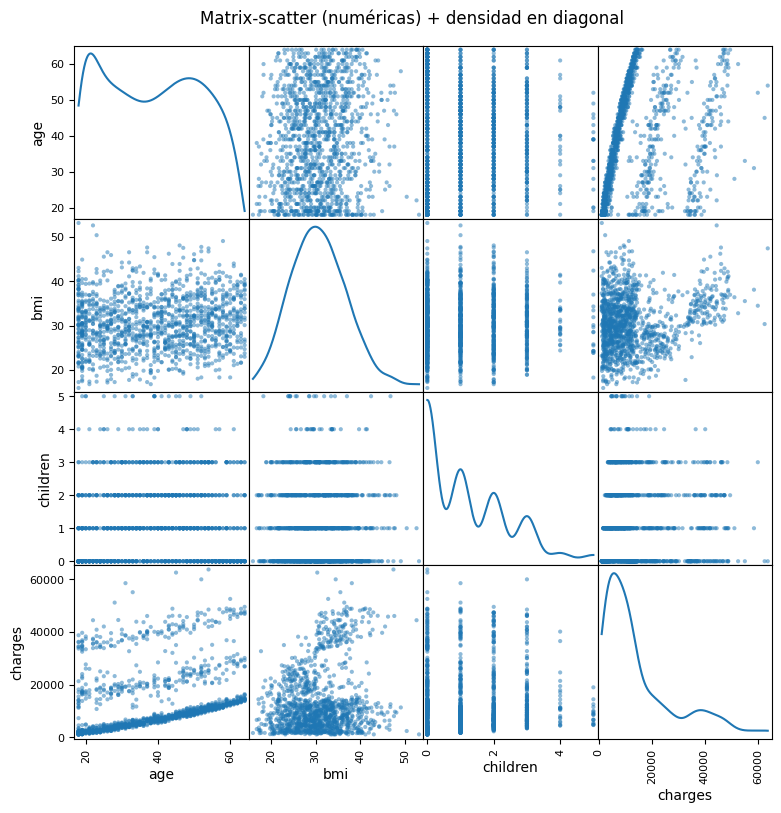

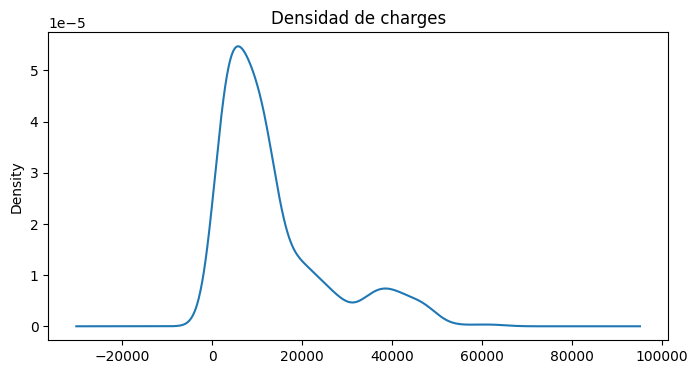

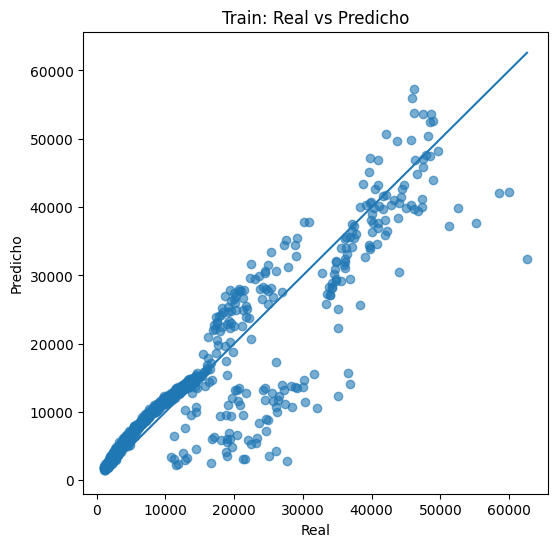

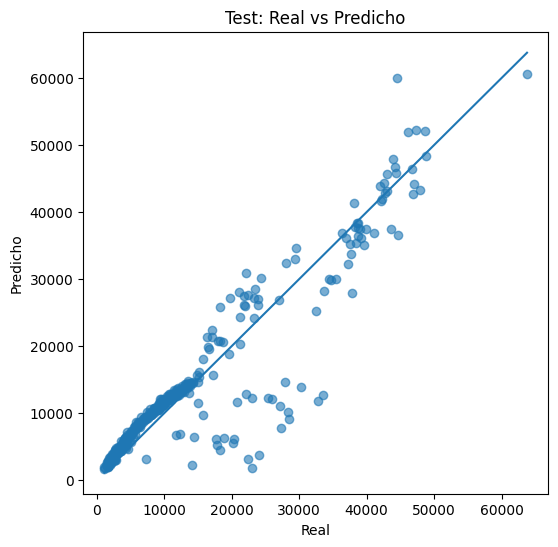

,idx,train_size,y_transform,x_scale,modelo,RMSE_test,MAPE_test,R2_test,R2adj_test,BreuschPagan_p_trainfit,Shapiro_p_trainfit,VIF_max,score
0,11,0.7,None,zscore,Interacciones_smoker,4492.739145,27.228625,0.862337,0.858816,5.137471e-01,2.427175e-39,1.655197,4717.376102
1,19,0.8,None,zscore,Interacciones_smoker,4574.123734,29.319765,0.865232,0.859988,4.814727e-01,7.776874e-42,1.678497,4802.829921
2,9,0.7,None,None,Interacciones_smoker,4492.739145,27.228625,0.862337,0.858816,5.137471e-01,2.427175e-39,32.022068,4942.013059
3,3,0.6,None,zscore,Interacciones_smoker,4715.092157,27.832708,0.850946,0.848107,2.748269e-01,6.956701e-37,1.649777,4950.846765
4,17,0.8,None,None,Interacciones_smoker,4574.123734,29.319765,0.865232,0.859988,4.814727e-01,7.776874e-42,31.140974,5031.536108
5,1,0.6,None,None,Interacciones_smoker,4715.092157,27.832708,0.850946,0.848107,2.748269e-01,6.956701e-37,32.919098,5186.601373
6,15,0.7,log,zscore,Interacciones_smoker,5246.366977,17.281692,0.812280,0.807479,2.584021e-07,2.271060e-39,1.655197,6033.322024
7,23,0.8,log,zscore,Interacciones_smoker,5378.566313,18.185005,0.813660,0.806410,8.064317e-10,8.868432e-42,1.678497,6185.351260
8,7,0.6,log,zscore,Interacciones_smoker,5391.810032,18.404970,0.805091,0.801378,7.594629e-07,2.616064e-37,1.649777,6200.581537
9,13,0.7,log,None,Interacciones_smoker,5246.366977,17.281692,0.812280,0.807479,2.584021e-07,2.271060e-39,32.022068,6295.640373


In [ ]:
out = ajustar_regresion(df, do_graphics=True)

# Top 10 configuraciones
out["ranking"].head(10)

In [ ]:
print("MEJOR CONFIGURACIÓN (según score):")
out["best_config"]

MEJOR CONFIGURACIÓN (según score):


{'idx': 11,
 'train_size': 0.7,
 'y_transform': 'None',
 'x_scale': 'zscore',
 'modelo': 'Interacciones_smoker',
 'RMSE_test': 4492.739144510943,
 'MAPE_test': 27.228625344061335,
 'R2_test': 0.8623372528708144,
 'R2adj_test': 0.8588164664992239,
 'BreuschPagan_p_trainfit': 0.5137471480205275,
 'Shapiro_p_trainfit': 2.4271748605245082e-39,
 'VIF_max': 1.655196696786587,
 'score': 4717.37610173649}

### 9.1 Resultados del mejor modelo (train)

En esta sección se presentan los resultados principales del modelo que fue seleccionado como la mejor configuración. Estos resultados corresponden al modelo ajustado utilizando el conjunto de entrenamiento (train), ya que es sobre este ajuste donde se estiman los coeficientes y se realizan la mayoría de los diagnósticos estadísticos.

El reporte incluye los siguientes elementos:

- **Betas con t-test y p-values**  
  Se muestran los coeficientes estimados del modelo junto con sus estadísticas t y p-values. Esto permite evaluar si cada variable tiene evidencia estadística de influir en la variable `charges`.

- **Prueba global (F-test)**  
  Se reporta la prueba F del modelo completo, la cual evalúa si el conjunto de variables explicativas tiene capacidad para explicar la variabilidad de `charges`.

- **Métricas train/test**  
  Se presentan las métricas de desempeño calculadas tanto en el conjunto de entrenamiento como en el conjunto de prueba. Esto permite comparar el ajuste del modelo con su capacidad de generalización.

- **VIF**  
  Se reporta el factor de inflación de la varianza para cada predictor, lo cual permite identificar posibles problemas de multicolinealidad entre variables.

- **Breusch–Pagan**  
  Se incluye la prueba para detectar heterocedasticidad en los residuales del modelo.

- **ANOVA**  
  Se presenta el análisis de varianza del modelo ajustado en train, que permite observar cómo se descompone la variabilidad explicada por el modelo.

In [ ]:
train_rep = out["train_report"]
train_model = train_rep["train_model"]

display(train_rep["beta_table_train"])
print("Global F (train):", train_rep["global_F_train"])
print("Métricas:", train_rep["metrics"])

print("\n--- Diagnósticos en TRAIN-FIT ---")
print("Normalidad (Shapiro p):", train_rep["diagnostics"]["shapiro_p"])
print("Normalidad (Jarque-Bera p):", train_rep["diagnostics"]["jarque_bera_p"])
print("Breusch–Pagan p:", train_rep["diagnostics"]["breusch_pagan_p"])

print("\n--- VIF (TRAIN) ---")
display(train_rep["diagnostics"]["vif"])

print("\n--- ANOVA (TRAIN, type II) ---")
display(train_rep["anova"])

,beta,std_err,t,p_value
C(smoker)[T.yes],23704.397808,404.922870,58.540526,2.616791e-313
Intercept,9370.768809,377.265307,24.838671,9.413588e-105
bmi:C(smoker)[T.yes],8781.719705,398.421661,22.041271,7.238281e-87
age,3787.844959,185.773781,20.389556,1.307878e-76
children,585.901073,164.141528,3.569487,3.760774e-04
C(region)[T.southwest],-1157.932963,468.889440,-2.469522,1.370895e-02
C(region)[T.southeast],-1024.540468,470.044451,-2.179667,2.953372e-02
C(region)[T.northwest],-644.088914,461.789847,-1.394766,1.634212e-01
C(sex)[T.male],-424.100734,329.052378,-1.288855,1.977708e-01
bmi,171.402770,192.408419,0.890828,3.732532e-01


Global F (train): {'F': 455.99713902551343, 'p_value': 0.0}
Métricas: {'train': {'R2': 0.8313573701326137, 'R2_adj': 0.8295342065664798, 'MAPE': 27.903808968884785, 'MSE': 24700815.038378365, 'RMSE': 4969.991452545805}, 'test': {'R2': 0.8623372528708144, 'R2_adj': 0.8588164664992239, 'MAPE': 27.228625344061335, 'MSE': 20184705.02062092, 'RMSE': 4492.739144510943}}

--- Diagnósticos en TRAIN-FIT ---
Normalidad (Shapiro p): 2.4271748605245082e-39
Normalidad (Jarque-Bera p): 0.0
Breusch–Pagan p: 0.5137471480205275

--- VIF (TRAIN) ---


,variable,VIF
0,C(sex)[T.male],1.655197
7,bmi,1.374088
3,C(region)[T.southeast],1.301767
8,bmi:C(smoker)[T.yes],1.291156
5,age,1.291149
6,age:C(smoker)[T.yes],1.290974
2,C(region)[T.northwest],1.258862
1,C(smoker)[T.yes],1.225727
4,C(region)[T.southwest],1.216755
9,children,1.008934



--- ANOVA (TRAIN, type II) ---


,sum_sq,df,F,PR(>F)
C(sex),4.151962e+07,1.0,1.661147,1.977708e-01
C(smoker),8.555286e+10,1.0,3422.859909,4.061454e-313
C(region),1.825925e+08,3.0,2.435097,6.347417e-02
age,1.309798e+10,1.0,524.033531,3.023873e-92
age:C(smoker),2.409048e+05,1.0,0.009638,9.218148e-01
bmi,3.750604e+09,1.0,150.056848,4.436221e-32
bmi:C(smoker),1.214279e+10,1.0,485.817616,7.238281e-87
children,3.184616e+08,1.0,12.741238,3.760774e-04
Residual,2.311996e+10,925.0,NaN,NaN


### 9.2 Resultados “en test” (refit)

Se presentan resultados obtenidos al volver a ajustar el mismo modelo, pero utilizando únicamente los datos del conjunto de test. El objetivo de este paso no es evaluar desempeño predictivo, sino poder reportar ciertos resultados estadísticos directamente sobre ese subconjunto de datos.

Para este refit se utiliza la misma especificación del modelo seleccionada previamente, aplicando el mismo tipo de preprocesamiento y transformaciones.

Este ajuste se realiza únicamente para poder reportar:

- p-values de los coeficientes estimados en test
- prueba global F del modelo ajustado en test
- diagnósticos estadísticos sobre los residuales, como normalidad y prueba de Breusch–Pagan

Es importante tener en cuenta que este refit no se utiliza para seleccionar el modelo ni para evaluar su capacidad de generalización.

La generalización del modelo se evalúa únicamente mediante las métricas obtenidas cuando el modelo entrenado en train se utiliza para predecir los datos del conjunto de test.

In [ ]:
test_fit = out["test_fit"]
display(test_fit["beta_table_test"])
print("Global F (test-fit):", test_fit["global_F_test"])
print("Normalidad test-fit (Shapiro p):", test_fit["normalidad_shapiro_p"])
print("Normalidad test-fit (Jarque-Bera p):", test_fit["normalidad_jb_p"])
print("Breusch–Pagan test-fit (p):", test_fit["breusch_pagan_p"])


,beta,std_err,t,p_value
C(smoker)[T.yes],24196.675930,580.462111,41.685194,5.961468e-146
Intercept,9442.857335,546.863835,17.267292,4.625246e-50
bmi:C(smoker)[T.yes],8851.463431,545.317312,16.231767,1.163072e-45
age,3535.050222,251.788889,14.039739,1.519049e-36
children,717.527276,228.918491,3.134423,1.851900e-03
C(region)[T.southeast],-1577.334646,670.830464,-2.351316,1.920274e-02
C(region)[T.southwest],-1475.370961,676.339296,-2.181407,2.974840e-02
C(sex)[T.male],-590.325840,467.635182,-1.262364,2.075702e-01
C(region)[T.northwest],-513.980106,682.722288,-0.752839,4.519996e-01
bmi,81.869975,269.784787,0.303464,7.616977e-01


Global F (test-fit): {'F': 249.35955415992487, 'p_value': 7.563557841457459e-163}
Normalidad test-fit (Shapiro p): 2.6111724763837944e-28
Normalidad test-fit (Jarque-Bera p): 0.0
Breusch–Pagan test-fit (p): 0.8116852080530732


## 10) Interpretación del modelo seleccionado (explicación clara)

Una vez seleccionado el mejor modelo, es importante interpretar los coeficientes y resultados estadísticos para entender qué variables están asociadas con el costo médico `charges` y cómo influyen en él.

En este dataset es común observar algunos patrones generales en los resultados del modelo:

1. **`smoker`** suele ser el factor más influyente. Las personas que fuman tienden a tener costos médicos considerablemente más altos que quienes no fuman.

2. `age` generalmente tiene un efecto positivo sobre `charges`. Esto significa que, manteniendo las demás variables constantes, a mayor edad se espera un mayor costo médico.

3. `bmi` también puede tener un efecto relevante y, en muchos casos, interactúa con la variable `smoker`. Esto sugiere que el impacto del índice de masa corporal sobre los costos médicos puede ser diferente entre fumadores y no fumadores. En particular, el efecto del BMI suele ser más fuerte en fumadores.

4. `children` suele mostrar un efecto positivo moderado. Es decir, tener más dependientes cubiertos por el seguro puede asociarse con un incremento en el costo médico esperado.

5. `sex` y `region` en algunos casos muestran efectos pequeños o incluso estadísticamente no significativos, dependiendo de la especificación del modelo.

En este notebook, la interpretación final del modelo debe basarse principalmente en tres elementos:

- la **tabla de betas**, observando tanto el signo de los coeficientes como sus p-values para evaluar significancia estadística;
- el **ANOVA**, que permite identificar qué variables o bloques de variables explican mayor proporción de la variabilidad en `charges`;
- las **métricas en test**, que permiten verificar que el modelo mantiene un buen desempeño fuera de la muestra de entrenamiento.

**Cómo interpretar un coeficiente**

Si se utiliza `x_scale="zscore"`, las variables numéricas se encuentran estandarizadas. En ese caso, el coeficiente estimado para una variable numérica representa el cambio esperado en `charges` cuando esa variable aumenta una desviación estándar, manteniendo las demás variables constantes.

Si el modelo incluye un término de interacción como `bmi:C(smoker)[T.yes]`, este coeficiente representa el cambio adicional en el efecto del BMI cuando `smoker = yes` en comparación con `smoker = no`. En otras palabras, indica cuánto se modifica la relación entre BMI y `charges` en el caso de los fumadores.

## 11) Conclusiones

A partir del proceso completo de exploración, ajuste del modelo, evaluación de configuraciones y diagnóstico estadístico, fue posible identificar un modelo de regresión que describe razonablemente la relación entre las variables del dataset `insurance.csv` y el costo médico individual `charges`.

### 1. Mejor configuración encontrada

Después de evaluar todas las combinaciones del espacio de búsqueda, la mejor configuración encontrada fue:

- `train_size = 0.7`
- `y_transform = None`
- `x_scale = zscore`
- modelo: **Interacciones con smoker**

Esta configuración obtuvo el **menor score dentro del ranking de modelos**, lo cual significa que logró el menor RMSE en test sin presentar problemas importantes en los diagnósticos estadísticos. En particular, el modelo no mostró heterocedasticidad significativa y tampoco presentó problemas de multicolinealidad.

### 2. Desempeño del modelo

El desempeño predictivo del modelo se evaluó principalmente sobre el conjunto de **test**, ya que este representa datos no utilizados durante el entrenamiento.

Resultados en test:

- **RMSE ≈ 4492.74**
- **MAPE ≈ 27.23 %**
- **R² ajustada ≈ 0.8588**

Estos resultados indican que el modelo logra explicar **aproximadamente el 86 % de la variabilidad del costo médico**, lo cual es un nivel de ajuste bastante alto para un problema de datos reales.

El error promedio de predicción (RMSE) es de aproximadamente **4493 unidades monetarias**, mientras que el error porcentual promedio se encuentra alrededor del **27 %**. Esto sugiere que el modelo captura una parte importante de la estructura del problema, aunque todavía existe variabilidad inherente que no puede explicarse completamente con las variables disponibles.

La comparación entre métricas de **train y test** muestra que el modelo no presenta señales fuertes de sobreajuste, ya que el desempeño fuera de muestra es incluso ligeramente mejor en términos de RMSE.

### 3. Inferencia estadística

Desde el punto de vista estadístico, el modelo presenta evidencia clara de que varias variables tienen una relación significativa con el costo médico.

La **prueba global F** del modelo es altamente significativa:

- **F ≈ 455.99**
- **p-value ≈ 0**

Esto indica que el conjunto de variables incluidas en el modelo explica una proporción significativa de la variabilidad de `charges`.

Los coeficientes más relevantes del modelo muestran que:

- **`smoker` es el factor dominante** en la explicación del costo médico.
- `age` tiene un efecto positivo fuerte y estadísticamente significativo.
- `bmi` por sí solo no es significativo, pero **su interacción con `smoker` sí lo es**, lo cual indica que el efecto del BMI cambia dependiendo de si la persona fuma o no.
- `children` tiene un efecto positivo moderado y significativo.
- `sex` y algunas categorías de `region` no resultaron estadísticamente significativas en este modelo.

El análisis **ANOVA** confirma estos resultados, mostrando que las mayores contribuciones a la variabilidad explicada provienen de:

- `smoker`
- `age`
- `bmi × smoker`
- `bmi`
- `children`

### 4. Diagnósticos del modelo

Los diagnósticos estadísticos sugieren que el modelo cumple razonablemente con los supuestos principales de la regresión lineal.

- **VIF máximo ≈ 1.65**

Esto indica que no existen problemas de multicolinealidad entre las variables explicativas, ya que todos los valores están muy por debajo del umbral comúnmente problemático (10).

- **Breusch–Pagan p ≈ 0.51**

No se encontró evidencia de heterocedasticidad, lo cual sugiere que la varianza de los residuales es relativamente constante.

- **Normalidad de residuales**

Las pruebas de normalidad rechazan la hipótesis de normalidad (p muy pequeño), lo cual es común en muestras grandes. Este resultado debe interpretarse con cautela, ya que pequeñas desviaciones de normalidad pueden resultar significativas cuando el tamaño de muestra es elevado.

En general, el modelo no muestra problemas estadísticos graves que comprometan su interpretación.

### 5. Interpretación práctica del modelo

Desde una perspectiva práctica, los resultados del modelo permiten extraer conclusiones claras sobre los factores asociados al costo médico.

El resultado más evidente es que **ser fumador incrementa fuertemente el costo médico esperado**, lo cual coincide con evidencia médica y actuarial ampliamente documentada.

Además, la presencia de la interacción **BMI × smoker** sugiere que el impacto del índice de masa corporal sobre los costos médicos es mucho mayor en personas fumadoras que en no fumadoras. Esto indica que los factores de riesgo se potencian cuando se combinan.

La **edad** también tiene un efecto positivo importante, lo cual es consistente con el hecho de que los gastos médicos suelen aumentar conforme las personas envejecen.

Por otro lado, el número de **children** presenta un efecto positivo moderado, mientras que variables como **sexo y región** parecen tener una influencia menor en comparación con factores como fumar, edad o BMI.

### Conclusión general

En conjunto, el análisis muestra que un modelo de regresión lineal con interacciones puede capturar de forma bastante efectiva la estructura del problema. El modelo seleccionado logra un buen equilibrio entre **capacidad predictiva, interpretabilidad y comportamiento estadístico**, explicando una proporción considerable de la variabilidad en los costos médicos.

Además, los resultados confirman que los principales determinantes del gasto médico en este dataset están relacionados con **hábitos de salud (fumar), características físicas (BMI) y factores demográficos como la edad**, lo cual coincide con la lógica del problema y con evidencia empírica observada en sistemas de seguros de salud.